In [56]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [87]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(500e6*2*pi)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
sim.add_param('K', 0e3 * 2 * np.pi)
sim.add_param('g3', 1e6 * 2 * np.pi)
sim.add_param('wa', 5.0e9*2*pi)

sim.add_param('amplR',  1e6)
sim.add_param('wR', 5e9 * 2 * np.pi, is_excitation=True)
sim.add_param('phaseR', 0)
sim.add_param('rampR', 10e-9)
sim.add_param('startR', -20e-9)
sim.add_param('stopR', 1000e-9)
sim.add_paramsweep('amplG',  0, 100000, 101)
sim.add_param('wG', -10e9 * 2 * np.pi)
sim.add_paramsweep('phaseG', 0, 2*np.pi, 31)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*K*abs(a)**2 - 1j*g3*conjugate(a)*pump')
sim.add_drive_EOM('ain', 'amplR*exp(-1j*(wR*t+phaseR))')
sim.add_drive_EOM('pump', 'amplG*exp(-1j*(wG*t+phaseG))')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=200, num_cycles=100, d_factor=10)

sim.validate(print_result=False)

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


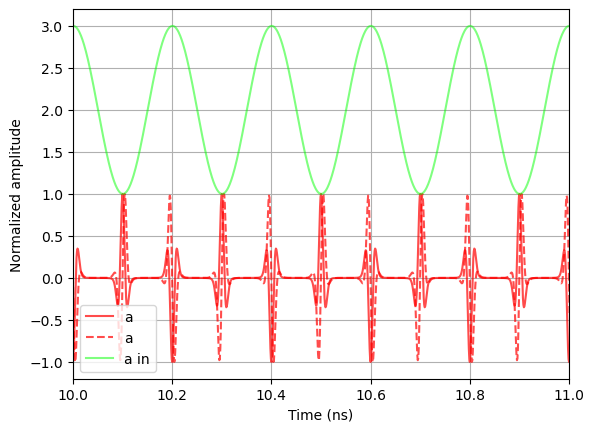

In [96]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a')
plt.plot(t*1e9, x[1,:]/np.max(x[1,:]),'--',color=(1,0,0,0.7),label='a')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='a in')
plt.xlim([10,11])
# plt.plot(t*1e9, x[3,:],color=(0,0,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [89]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [00:13<00:00, 1521.95it/s]

 
...finished GPU solve!


In [90]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[2,:]+1j*Qd[2,:]
a = Id[0,:]+1j*Qd[0,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

In [91]:
np.shape(aout)

(101, 31, 10)

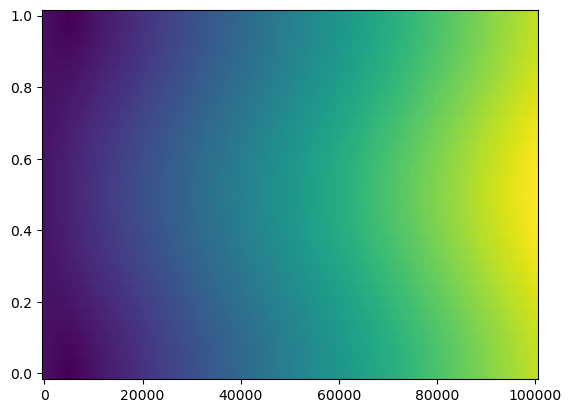

In [92]:
S11_mag = np.abs(aout)[:,:,-1]
S11_phase = np.angle(aout[:,:,-1]/ain[:,:,-1])

amplG = sim.paramsweep_dict['amplG']
phaseG = sim.paramsweep_dict['phaseG']/(2*np.pi)

plt.pcolor(amplG, phaseG, S11_mag.transpose())
plt.show()

In [93]:
np.shape(S11_mag)

(101, 31)